**Duration:** 2 weeks [18 Jun - 3 Jul, 2026]  
**Due Date:** 3rd July, 2026  
**Format:** Jupyter Notebook / Google Colab  
**Grading:** This is a graded lab.

**Student Name:** EWURABENA PINKRA AMISSAH-ASRTHUR  
**Student ID:** 13112028

Loaded: 41202 rows x 13 columns
Shape:  (41202, 13)
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

Description

Missin

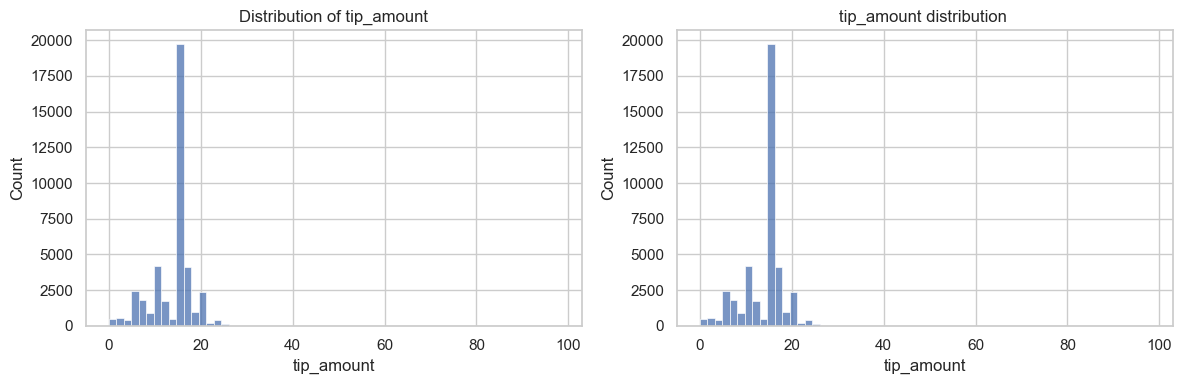


 Negative Values: 0
Features after engineering: 12
Train: 24675 | Test: 8226 | Val: 8225
Linear Regression:
  Train      — RMSE: 4.8047  R²: 0.0512
  Val        — RMSE: 5.0375  R²: 0.0485
  Test       — RMSE: 5.0132  R²: 0.0510

Random Forest (n = 100, max_depth = 5):
  Train      — RMSE: 4.7765  R²: 0.0624
  Val        — RMSE: 5.0456  R²: 0.0455
  Test       — RMSE: 5.0151  R²: 0.0503


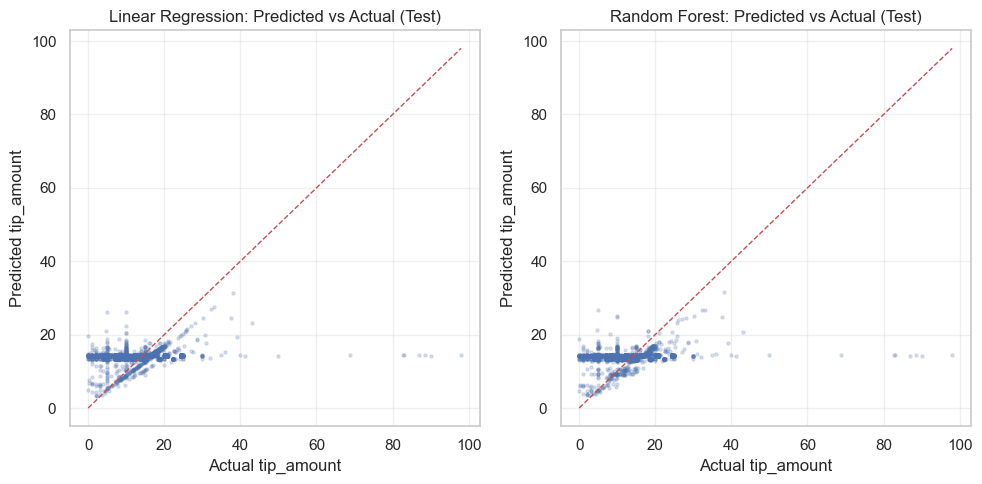

In [13]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)
taxi.columns = taxi.columns.str.strip()
print(f"Loaded: {taxi.shape[0]} rows x {taxi.shape[1]} columns")

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
taxi.head()
print("Shape: ",taxi.shape)
taxi.info()

print("\nDescription")
taxi.describe()

print("\nMissing values per column:")
print(taxi.isna().sum().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(taxi['tip_amount'], bins = 60, ax=axes[0])
axes[0].set_title("Distribution of tip_amount")
sns.histplot(taxi[taxi['tip_amount'] > 0]['tip_amount'], bins = 60, ax=axes[1])
axes[1].set_title('tip_amount distribution ')

plt.tight_layout()
plt.show()

#print(taxi.groupby("fare_amount")["tip_amount"].agg(["mean", "median", "std"]).round(2))

# TODO: Handle missing / invalid rows
col_needed = ["VendorID", "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag", "PULocationID", "DOLocationID", "payment_type", "fare_amount", "mta_tax", 
              "tolls_amount", "improvement_surcharge", "tip_amount"]
taxi = taxi[col_needed].dropna()


print("\n Negative Values:", (taxi["tip_amount"] < 0).sum())

taxi = taxi[taxi["trip_distance"] > 0]
taxi = taxi[taxi["fare_amount"] > 0]
taxi["tip_amount"] = taxi["tip_amount"].clip(lower=0)

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

cat_cols = ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type']
taxi = pd.get_dummies(taxi, columns= cat_cols, drop_first = True)

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
taxi.drop(columns=['PULocationID', 'DOLocationID'], inplace=True)

print('Features after engineering:', taxi.shape[1] - 1)  # minus target
taxi.head(3)



# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X = taxi.drop(columns=["tip_amount"])
y = taxi['tip_amount']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state= RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state= RANDOM_STATE
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Val: {X_val.shape[0]}")

def reg_metrics(model, X, y, label):
    pred = model.predict(X)
    rmse = mean_squared_error(y, pred) ** 0.5
    r2   = r2_score(y, pred)
    print(f'  {label:<10s} — RMSE: {rmse:.4f}  R²: {r2:.4f}')
    return pred

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print('Linear Regression:')
reg_metrics(lr, X_train_scaled, y_train, 'Train')
reg_metrics(lr, X_val, y_val, 'Val')
pred_lr_test = reg_metrics(lr, X_test, y_test, 'Test')

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)

print('\nRandom Forest (n = 100, max_depth = 5):')
reg_metrics(rf, X_train_scaled, y_train, 'Train')
reg_metrics(rf, X_val,   y_val,   'Val')
pred_rf_test = reg_metrics(rf, X_test,  y_test,  'Test')


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, pred, title in zip(axes, [pred_lr_test, pred_rf_test], ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, pred,  alpha=0.2,  s = 5)
    lim = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lim, lim, 'r--', lw=1)
    ax.set_xlabel('Actual tip_amount')
    ax.set_ylabel('Predicted tip_amount')
    ax.set_title(f'{title}: Predicted vs Actual (Test)')
    ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()




PART 1.1 = Student Reasoning — Taxi data exploration 
What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

ANWSER: The shape of the data is (41202, 13 ), having 41202 rows and 13 columns. There are no missing values or impossible values. The tip_amount distribution is rightly skewed with a high peak at 17. The peak at 17 is the structural feature of the data, with no outliers. Because of the skew, I'll probably log-transform the target before modeling, since raw right-skewed targets tend to make models just predictthe near average instead of learning the real relationship.

PART 1.2 - Student Reasoning — Taxi preprocessing 
How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?

ANSWER: First, I cleaned the data by keeping only the columns I needed and dropped rows with missing values. I also checked for negative tips, there were none. I still removed rows with zero or negative trip distance and fare amount, since those aren't real trips. As a safety check, I also clipped tip_amount at zero. I built two new features. The first is fare_per_mile: fare_amount divided by trip_distance. This shows how expensive a ride was relative to its length, not just its total cost. The second is total_surcharges: mta_tax, tolls, and the improvement surcharge added together. Neither feature uses tip_amount, so there's no leakage into the target. I scaled the numeric features with StandardScaler, fit only on the training set. This matters because features like fare_amount and trip_distance are on very different scales. Without scaling, a feature could dominate the model just because its numbers are bigger, not because it's actually more useful.

PART 1.3 - Student Reasoning — Splitting 
What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?

ANSWER: For the ratio, I used 60% for testing, 20% for validation, and 20% for testing. This is because the test set needs to be untouched until the very end of the testing process, so that it can give an honest reading on how the model acts with data it has never perceived before. A seperate validation set was useful for checking against the trainig data whilst the test values are stored for the final answer. The scaler must be fit on the training data because if it focused on the entire dataset, it would learn from the validation values.

PART 1.4 -Student Reasoning — Regression evaluation & overfitting 
Which model performed best on the validation set, and which hyper-parameters did you try? 2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 3. What would you change to reduce overfitting if you saw it?

ANSWER: The model that performed the best in my case, was the Linear Regression model, and I used the RMSE  and R^2 hyperparameters for this. The metrics for the Linear Regression Model are Train — RMSE: 4.8047  R²: 0.0512, Val — RMSE: 5.0375  R²: 0.0485, Test — RMSE: 5.0132  R²: 0.0510 and the metrics for the Random Forest Model is Train      — RMSE: 4.7765  R²: 0.0624, Val — RMSE: 5.0456  R²: 0.0455, Test — RMSE: 5.0151  R²: 0.0503, which shows that The linear Regresion Model is much suited for the data rather than the Random Forest model. The linear model is consistent but has a low R^2, making it underfitting. The RF model is close to well-fitted but its still weak.

In [14]:
import sys
print(sys.executable)


import sys
!{sys.executable} -m pip install scikit-learn



/Users/pinky/Desktop/ai_labs/ai_env/bin/python

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Shape:  (2111, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                       

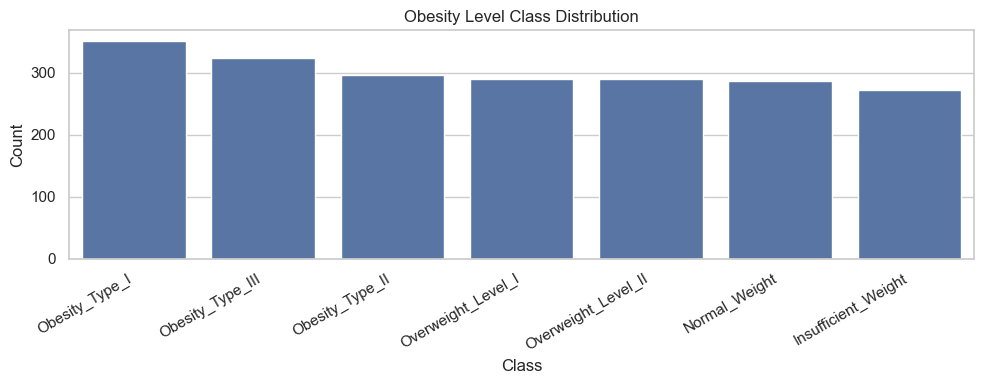


 

Class to int mapping: {'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}


In [15]:
# Section 2 — Supervised Learning: Multi-class Classification

# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obes = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape: ", obes.shape)
obes.head()
obes.info()
obes.describe()
print("\nMissing values: ", obes.isna().sum().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print('\nClass distribution: ')
print(obes['NObeyesdad'].value_counts())

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(
    data=obes,
    x='NObeyesdad',
    order= obes['NObeyesdad'].value_counts().index, # type: ignore
    ax=ax,
)
ax.set_title('Obesity Level Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()



# TODO: Encode categorical columns.

print('\n ')
Binary_columns = {'Yes': 0 , 'No': 1}
for col in ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']:
    obes[col] = obes[col].map(Binary_columns)

obes['Gender'] = (obes['Gender'] == 'Male').astype(int)  # Male=1, Female=0    
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
# Ordinal encoding for CAEC and CALC
order = ['no', 'Sometimes', 'Frequently', 'Always']
obes['CAEC'] = pd.Categorical(obes['CAEC'], categories=order, ordered=True).codes
obes['CALC'] = pd.Categorical(obes['CALC'], categories=order, ordered=True).codes

# One-hot for nominal MTRANS
obes = pd.get_dummies(obes, columns=['MTRANS'], drop_first=True)

# Feature engineering: BMI
obes['BMI'] = obes['Weight'] / obes['Height'] ** 2

# TODO: Encode the target `NObeyesdad` into integer class labels
le = LabelEncoder()
obes['target'] = le.fit_transform(obes['NObeyesdad'])
print('\nClass to int mapping:', dict(zip(le.classes_, le.transform(le.classes_))))



PART 2.1 - Student Reasoning — Obesity data exploration 
How many rows/features are there? Which columns are categorical vs numeric? Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?


ANSWER: There are 2111 rows, 17 columns for this data. The categorical columns are Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and NObeyesdad. The numeric coulmns are Age, Height, Weight, FCVC, NCP, CH20, FAF, and TUE. The target has 7 classes, ranging from 272 (Insufficient_Weight) to 351 (Obesity_Type_I) which is a fairly small spread, so the classes are reasonably balanced. Class (im)balance matters because if classes are imbalanced, a model can get a deceptively high accuracy just by mostly predicting the majority class, while doing poorly on minority classes which makes accuracy become misleading.

PART 2.2 - Student Reasoning — Obesity preprocessing 
How did you encode each type of categorical variable, and why? 2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. 3. Which scaler did you use and why?
ANSWER: I used three different encoding strategies, Binary mapping(Yes / No) columns, Manual Binary mapping just for two categories, One-hot encoding for MTRANS for the  nominal values. I created the BMI = Weight / Height^2, even though the it is a target leakage since obesity is already measured using BMI in real life. The scaler I used is the StandardScaler, because I wanted it to fit on the training data only.

PART 2.3 - Student Reasoning — Splitting 
What split ratio did you choose? Why is stratify=y important for this dataset? What could go wrong if you split without stratifying?

ANSWER: The split ratio I used is 60/20/20. Stratify = y is important because there are 7 classes and if the data is not stratified, a random split could end up with uneven proportions across the train, val, and the test metrics. If we split without stratifying, i believe that a class could end up missing some values or be underrepresented.

PART 2.4 - 	Student Reasoning — Classification evaluation & overfitting 
Which classifier did you choose and why? 2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. 3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?

ANSWER: I used Random Forest (n=100, max_depth=8) since it beat Logistic Regression on val and test. Accuracy hit ~98% on test, with F1 around 0.97–0.99 across all classes, and train/val/test stayed consistent so no real overfitting gap. But scores this high on a 7-class problem are suspicious rather than reassuring. It likely means BMI is still leaking into the features, since obesity levels are basically defined by BMI to begin with. Worth double-checking before trusting these numbers.The hardest classes to separate were Overweight_Level_I and Overweight_Level_II (both ~0.97 precision/recall), since they're adjacent on a continuous scale with no real behavioral boundary between them.

Fully empty columns: ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
X2 shape: (2111, 16) | NaNs left: 0
Train: 1266 | Test: 423 | Val: 422

Logistics Regression:
Train      — RMSE: 0.9556  R²: 0.9127
Val        — RMSE: 0.9452  R²: 0.8923
Test       — RMSE: 0.9453  R²: 0.8933

Random Forest (n=100, max_depth=8):
Train      — RMSE: 0.9996  R²: 0.9992
Val        — RMSE: 0.9941  R²: 0.9882
Test       — RMSE: 0.9917  R²: 0.9834

Classification Report — Random Forest (Test Set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        54
      Normal_Weight       0.98      0.98      0.98        58
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.97      0.97      0.97        58
Overweight_Level_II       0.98      0.97      0.97        58

           accuracy 

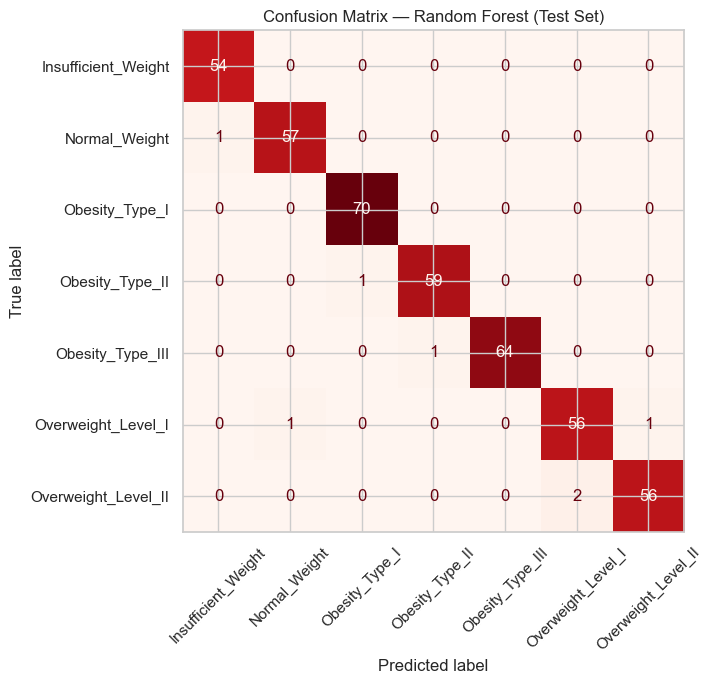

(2111, 16)
(2111,)
Gender                               0
Age                                  0
Height                               0
Weight                               0
family_history_with_overweight    2111
FAVC                              2111
FCVC                                 0
NCP                                  0
CAEC                                 0
SMOKE                             2111
CH2O                                 0
SCC                               2111
FAF                                  0
TUE                                  0
CALC                                 0
NObeyesdad                           0
MTRANS_Bike                          0
MTRANS_Motorbike                     0
MTRANS_Public_Transportation         0
MTRANS_Walking                       0
BMI                                  0
target                               0
dtype: int64
Original rows: 2111
Rows after dropna: 0


In [16]:

obes_features = obes.drop(columns=['NObeyesdad', 'target'])

for col in obes_features.columns:
    if obes_features[col].dtype == 'object':
        obes_features[col] = obes_features[col].fillna(obes_features[col].mode()[0])
    else:
        obes_features[col] = obes_features[col].fillna(obes_features[col].mean())

fully_empty = obes_features.columns[obes_features.isna().sum() == len(obes_features)]
print("Fully empty columns:", list(fully_empty))
obes_features = obes_features.drop(columns=fully_empty)

# TODO: Separate X (features) and y (encoded NObeyesdad).
# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X2 = obes_features
y2 = obes['target']

X2_temp, X2_test, y2_temp, y2_test = train_test_split(
    X2, y2, test_size = 0.2, random_state= RANDOM_STATE, stratify = y2
)

X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_temp, y2_temp, test_size = 0.25, random_state = RANDOM_STATE, stratify = y2_temp  
)

# Confirm no NaNs remain in X2
print("X2 shape:", X2.shape, "| NaNs left:", X2.isna().sum().sum())


# TODO: Fit the scaler on the training set only, then transform train /
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_val_s= scaler2.transform(X2_val)
X2_test_s = scaler2.transform(X2_test)
print(f"Train: {X2_train.shape[0]} | Test: {X2_test.shape[0]} | Val: {X2_val.shape[0]}")



# TODO: Import, initialise, and train a classifier
#   Which classes are most often confused?
def cls_metrics(model, X, y, label):
    prediction = model.predict(X)   
    accuracy = accuracy_score(y, prediction) ** 0.5
    f1  = f1_score(y, prediction, average= 'weighted')
    print(f'{label:<10} — RMSE: {accuracy:.4f}  R²: {f1:.4f}')
    return prediction

# TODO: Predict on train, validation, and test sets.
# Model 1: Logistic Regression
log = LogisticRegression(max_iter=1000, random_state = RANDOM_STATE)
log.fit(X2_train_scaled, y2_train)

print('\nLogistics Regression:')
cls_metrics(log, X2_train_scaled, y2_train, 'Train')
cls_metrics(log, X2_val_s,   y2_val,   'Val')
cls_metrics(log, X2_test_s,  y2_test,  'Test')

# Model 2: Random Forest Classifier
rfcs = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE)
rfcs.fit(X2_train_scaled, y2_train)

print('\nRandom Forest (n=100, max_depth=8):')
cls_metrics(rfcs, X2_train_scaled, y2_train, 'Train')
cls_metrics(rfcs, X2_val_s,   y2_val,   'Val')
pred = cls_metrics(rfcs, X2_test_s,  y2_test,  'Test')


# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

print('\nClassification Report — Random Forest (Test Set):')
print(classification_report(y2_test, pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y2_test, pred, display_labels=le.classes_, ax=ax,
    xticks_rotation=45, colorbar=False, cmap= 'Reds')
ax.set_title('Confusion Matrix — Random Forest (Test Set)')
plt.tight_layout()
plt.show()


print(X2.shape)
print(y2.shape)
print(obes.isna().sum())

print("Original rows:", len(obes))
print("Rows after dropna:", len(obes.dropna()))


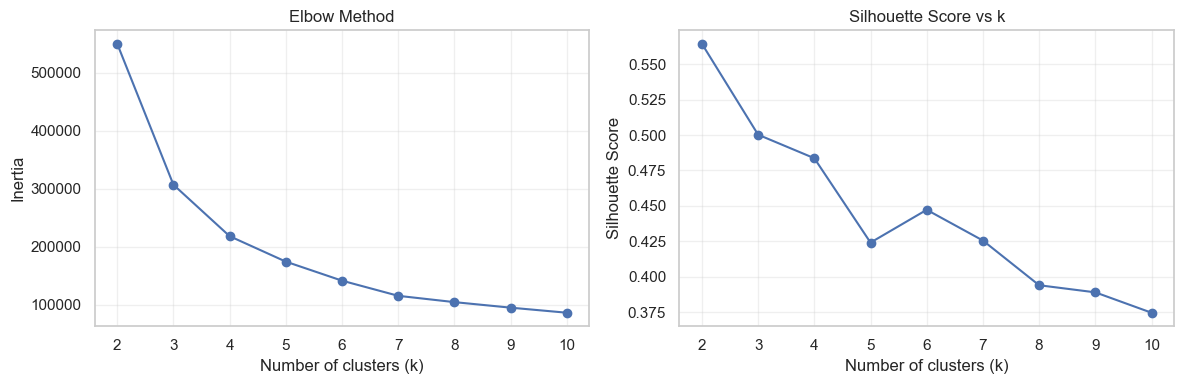

k=2: silhouette=0.564
k=3: silhouette=0.500
k=4: silhouette=0.484
k=5: silhouette=0.424
k=6: silhouette=0.447
k=7: silhouette=0.426
k=8: silhouette=0.394
k=9: silhouette=0.389
k=10: silhouette=0.375
PCA explains 98.7% of variance


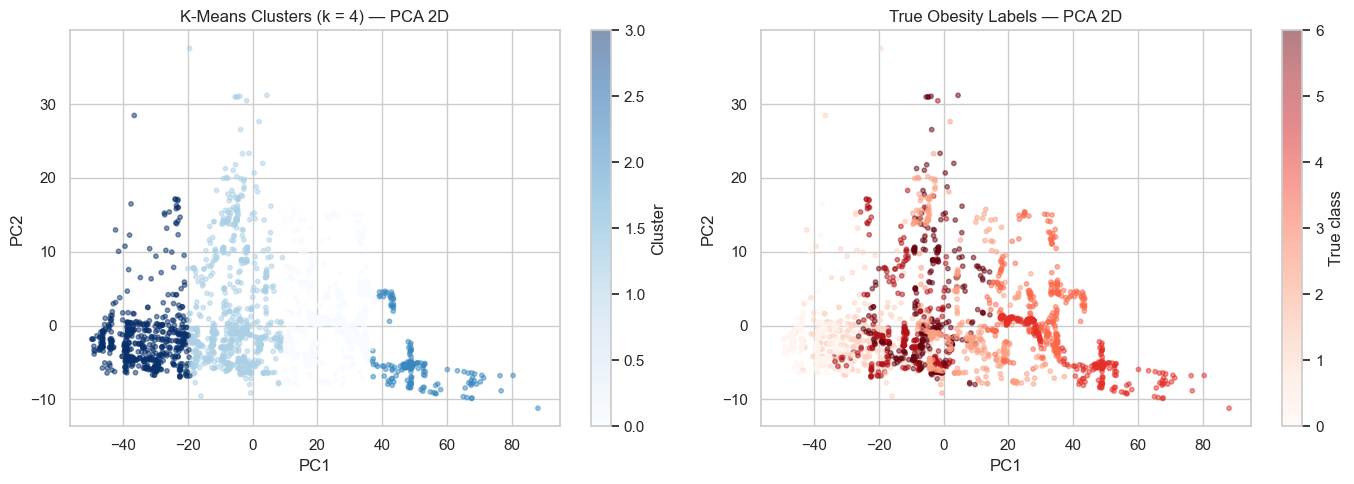

Obesity level  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
Cluster                                                                                                                                      
0                                0              0             144              271               181                   0                   17
1                                0             76             206                1                 0                 228                  252
2                                0              0               1               25               143                   0                    0
3                              272            211               0                0                 0                  62                   21


In [17]:

#Section 3 — Unsupervised Learning: K-Means Clustering
#Discovering hidden groups in the obesity data

#TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X2.copy()

inertia = []
silhouettes = []
k_range = range(2, 11)
# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
for k in k_range:
    km = KMeans(n_clusters = k, random_state = RANDOM_STATE, n_init = 10)
    labels = km.fit_predict(X_cluster)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))



# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertia, marker = 'o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)
axes[1].plot(k_range, silhouettes, marker = 'o')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f'k={k}: silhouette={s:.3f}')

BEST_K = 4
km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
labels = km_final.fit_predict(X_cluster)

# PCA 2D visualisation
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2_pca = pca.fit_transform(X_cluster)
print(f'PCA explains {pca.explained_variance_ratio_.sum():.1%} of variance')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X2_pca[:, 0], X2_pca[:, 1], c = labels, cmap = 'Blues', alpha = 0.5, s = 10)
axes[0].set_title(f'K-Means Clusters (k = {BEST_K}) — PCA 2D')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

true_int = le.transform(obes['NObeyesdad'])
sc2 = axes[1].scatter(X2_pca[:, 0], X2_pca[:, 1], c = true_int, cmap = 'Reds', alpha = 0.5, s = 10)
axes[1].set_title('True Obesity Labels — PCA 2D')
axes[1].set_xlabel('PC1') 
axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='True class')
plt.tight_layout()
plt.show()

crosstab = pd.crosstab(labels, obes['NObeyesdad'], rownames=['Cluster'], colnames=['Obesity level'])
print(crosstab.to_string())


Part 3.1 — Choose k, fit K-Means, and visualise
Student Reasoning — Clustering 
1. How did you choose k? Quote the Elbow/silhouette evidence. 2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down? 3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?

ANSWER: The silhouette peaked at k=2 (0.564), dropping to 0.484 by k=4. I chose k=4 anyway for more meaningful groupings than just two broad clusters.
Clusters partly match real obesity levels, cluster 3 captures low weight cleanly, cluster 2 is almost pure Obesity_Type_III, but cluster 1 blends Normal_Weight, Obesity_Type_I, and both Overweight levels, the middle categories are hard to separate since their boundaries are somewhat arbitrary. For public health, these clusters could still help flag high-risk people (like cluster 2) for early outreach using cheap lifestyle data, without needing a full diagnosis right away.

REFLECTION QUESTIONS
Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?

ANSWER: The classifier learned exact label boundaries, since it had answers to learn from. K-Means only grouped by overall similarity with no labels. It caught big natural splits (underweight vs obese) but missed fine boundaries like Overweight_Level_I vs II. It did show that, the middle categories blur together naturally, not just in model errors.

Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?

ANSWER:For tips, I was judging by how far off the prediction was in dollars, RMSE and R² told that story. For obesity, it was about whether the model got the category right or wrong, and a confusion matrix showed me exactly which classes it kept mixing up. Regression metrics just can't show that kind of detail.

Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

ANSWER: The worst gap was tip regression with Random Forest — train R² was 0.096, test dropped to 0.043. The obesity classifier stayed pretty consistent between train and test, so overfitting wasn't really the problem there, the leakage was the bigger worry. The thing that actually helped close the tip regression gap was just lowering max_depth from 8 to 5.
